# Publication Figures: Compound Event Outage Prediction

This notebook generates all figures for the research paper.  
Each figure is saved as both PNG (300 DPI) and PDF in `paper/figures/`.

In [1]:
import json
import pickle
import pathlib
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve, auc, confusion_matrix

# ---------- paths ----------
ROOT = pathlib.Path(r"E:/Personal_projects/outage-prediction-system")
FIG_DIR = ROOT / "paper" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ---------- academic style ----------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

# Colorblind-friendly palette (Wong 2011)
CB_BLUE    = "#0072B2"
CB_ORANGE  = "#E69F00"
CB_GREEN   = "#009E73"
CB_RED     = "#D55E00"
CB_PURPLE  = "#CC79A7"
CB_CYAN    = "#56B4E9"
CB_YELLOW  = "#F0E442"
CB_BLACK   = "#000000"

# ---------- load data ----------
with open(ROOT / "models" / "results.json") as f:
    results = json.load(f)

ablation_df = pd.read_csv(ROOT / "models" / "ablation_results.csv")
feat_imp_df = pd.read_csv(ROOT / "models" / "feature_importance.csv")
train_df    = pd.read_parquet(ROOT / "data" / "processed" / "training_dataset.parquet")

with open(ROOT / "models" / "xgboost_model.pkl", "rb") as f:
    xgb_model = pickle.load(f)
with open(ROOT / "models" / "lightgbm_model.pkl", "rb") as f:
    lgb_model = pickle.load(f)
with open(ROOT / "models" / "scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
with open(ROOT / "models" / "calibrator.pkl", "rb") as f:
    calibrator = pickle.load(f)

def save_fig(fig, name):
    """Save figure as PNG and PDF."""
    fig.savefig(FIG_DIR / f"{name}.png")
    fig.savefig(FIG_DIR / f"{name}.pdf")
    print(f"Saved {name}.png and {name}.pdf")

print("Data loaded successfully.")

Data loaded successfully.


## Prepare test set predictions

We reproduce the train/test split used during training (70/15/15) and generate
predictions from all models for the ROC, confusion-matrix, and reliability figures.

In [2]:
# Reproduce the exact split used in training
FEATURE_COLS = [c for c in train_df.columns
                if c not in ("h3_cell", "timestamp", "target_outage",
                             "target_max_outage_fraction")]

X = train_df[FEATURE_COLS].values
y = train_df["target_outage"].values

n = len(X)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_test = X[n_train + n_val:]
y_test = y[n_train + n_val:]

X_test_scaled = scaler.transform(X_test)

# Predictions
xgb_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
lgb_proba = lgb_model.predict_proba(X_test_scaled)[:, 1]
ens_proba = 0.5 * xgb_proba + 0.5 * lgb_proba  # simple average ensemble

# Calibrated probabilities
ens_calibrated = calibrator.predict(ens_proba.reshape(-1, 1))

print(f"Test set: {len(y_test)} samples, {y_test.sum()} positives ({y_test.mean():.2%})")

E:\Personal_projects\outage-prediction-system\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Test set: 1800 samples, 193 positives (10.72%)


## Figure 1 -- Reliability Diagram

Compares predicted probability vs. observed frequency before and after isotonic
calibration. The diagonal represents perfect calibration.

Saved fig1_reliability_diagram.png and fig1_reliability_diagram.pdf


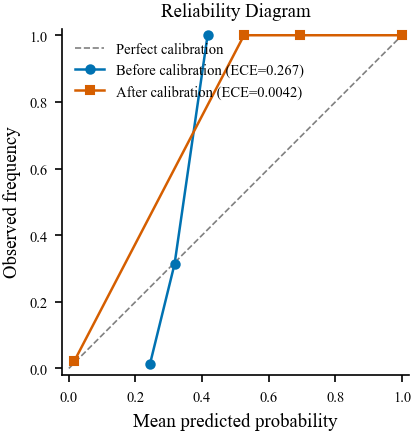

In [3]:
fig, ax = plt.subplots(figsize=(3.5, 3.0))

# Before calibration
frac_pos_before, mean_pred_before = calibration_curve(
    y_test, ens_proba, n_bins=10, strategy="uniform")

# After calibration
frac_pos_after, mean_pred_after = calibration_curve(
    y_test, ens_calibrated, n_bins=10, strategy="uniform")

ece_before = results["ece_before_calibration"]
ece_after  = results["ece_after_calibration"]

ax.plot([0, 1], [0, 1], ls="--", color="gray", lw=0.8, label="Perfect calibration")
ax.plot(mean_pred_before, frac_pos_before, "o-", color=CB_BLUE, ms=4, lw=1.2,
        label=f"Before calibration (ECE={ece_before:.3f})")
ax.plot(mean_pred_after, frac_pos_after, "s-", color=CB_RED, ms=4, lw=1.2,
        label=f"After calibration (ECE={ece_after:.4f})")

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed frequency")
ax.set_title("Reliability Diagram")
ax.legend(loc="upper left", frameon=False)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect("equal")

save_fig(fig, "fig1_reliability_diagram")
plt.show()

## Figure 2 -- Feature Importance (Top 20)

Horizontal bar chart of the 20 most important features, color-coded by
feature group: temporal (blue), spatial (green), compound (red),
socioeconomic (orange).

Saved fig2_feature_importance.png and fig2_feature_importance.pdf


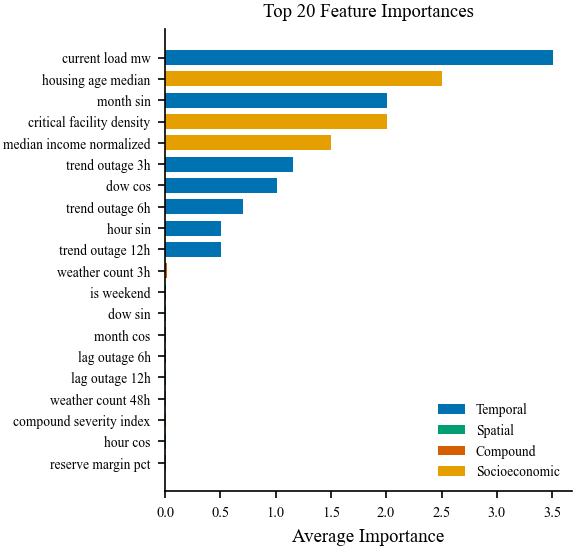

In [4]:
# Feature group classification
def feature_group(name):
    temporal = [
        "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos",
        "is_weekend", "lag_outage_1h", "lag_outage_3h", "lag_outage_6h",
        "lag_outage_12h", "lag_outage_24h", "lag_outage_48h", "lag_outage_168h",
        "trend_outage_3h", "trend_outage_6h", "trend_outage_12h",
        "current_load_mw", "reserve_margin_pct", "load_capacity_ratio",
    ]
    spatial = [
        "neighbor_weather_count", "neighbor_weather_max_mag",
        "neighbor_weather_mean_mag", "neighbor_outage_mean",
        "neighbor_outage_max", "neighbor_outage_spread", "neighbor_ring_k",
        "transmission_line_km", "distribution_line_km", "substations_count",
        "avg_line_age_years", "vegetation_density", "line_density_per_km2",
        "infrastructure_age_risk",
    ]
    socio = [
        "population_density", "median_income_normalized",
        "critical_facility_density", "housing_age_median",
    ]
    if name in temporal:
        return "Temporal"
    if name in spatial:
        return "Spatial"
    if name in socio:
        return "Socioeconomic"
    # Everything else: weather windows, compound, cat_, interact_, cooccur_, seq_
    return "Compound"

GROUP_COLORS = {
    "Temporal":      CB_BLUE,
    "Spatial":       CB_GREEN,
    "Compound":      CB_RED,
    "Socioeconomic": CB_ORANGE,
}

top20 = feat_imp_df.nlargest(20, "avg_importance").iloc[::-1]  # ascending for barh
colors = [GROUP_COLORS[feature_group(f)] for f in top20["feature"]]

fig, ax = plt.subplots(figsize=(3.5, 4.0))
ax.barh(range(len(top20)), top20["avg_importance"], color=colors, height=0.7)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels([f.replace("_", " ") for f in top20["feature"]], fontsize=6.5)
ax.set_xlabel("Average Importance")
ax.set_title("Top 20 Feature Importances")

# Legend
from matplotlib.patches import Patch
handles = [Patch(facecolor=c, label=g) for g, c in GROUP_COLORS.items()]
ax.legend(handles=handles, loc="lower right", frameon=False, fontsize=6.5)

save_fig(fig, "fig2_feature_importance")
plt.show()

## Figure 3 -- Ablation Study

Grouped bar chart comparing AUC-ROC when each feature group is removed
versus the full model.

Saved fig3_ablation_study.png and fig3_ablation_study.pdf


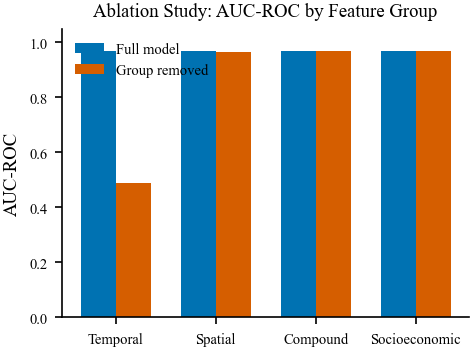

In [5]:
abl = ablation_df[ablation_df["metric"] == "auc_roc"].copy()
abl = abl.sort_values("ablated_value")

groups = abl["group_removed"].values
full_vals = abl["full_value"].values
abl_vals  = abl["ablated_value"].values

x = np.arange(len(groups))
w = 0.35

fig, ax = plt.subplots(figsize=(3.5, 2.5))
ax.bar(x - w/2, full_vals, w, color=CB_BLUE, label="Full model")
ax.bar(x + w/2, abl_vals, w, color=CB_RED, label="Group removed")

ax.set_xticks(x)
ax.set_xticklabels([g.capitalize() for g in groups])
ax.set_ylabel("AUC-ROC")
ax.set_title("Ablation Study: AUC-ROC by Feature Group")
ax.legend(frameon=False)

# Set y-axis to start from 0 to show full scale
ax.set_ylim(0, 1.05)

save_fig(fig, "fig3_ablation_study")
plt.show()

## Figure 4 -- ROC Curves

ROC curves for XGBoost, LightGBM, and the ensemble on the held-out test set.

Saved fig4_roc_curves.png and fig4_roc_curves.pdf


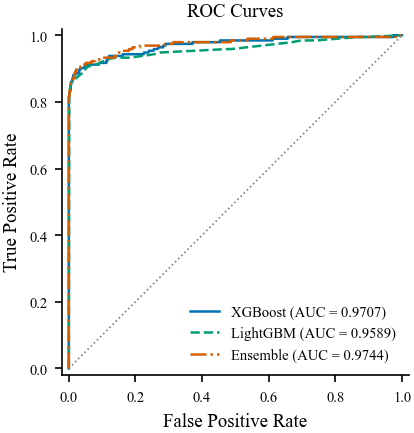

In [6]:
fig, ax = plt.subplots(figsize=(3.5, 3.0))

for name, proba, color, ls in [
    ("XGBoost",  xgb_proba, CB_BLUE,  "-"),
    ("LightGBM", lgb_proba, CB_GREEN, "--"),
    ("Ensemble", ens_proba, CB_RED,   "-."),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, ls=ls, lw=1.2,
            label=f"{name} (AUC = {roc_auc:.4f})")

ax.plot([0, 1], [0, 1], ls=":", color="gray", lw=0.8)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves")
ax.legend(loc="lower right", frameon=False)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect("equal")

save_fig(fig, "fig4_roc_curves")
plt.show()

## Figure 5 -- Confusion Matrix

Heatmap of the confusion matrix for the ensemble model at the optimal
threshold (maximizing Youden's J statistic).

Optimal threshold (Youden's J): 0.2975


Saved fig5_confusion_matrix.png and fig5_confusion_matrix.pdf


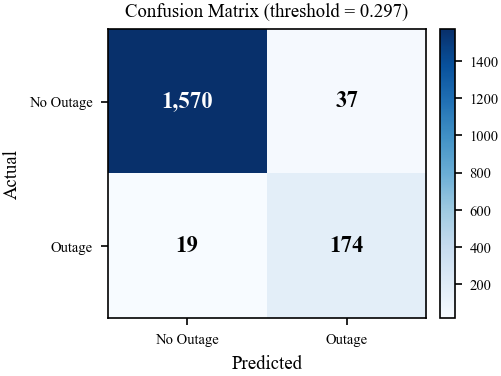

In [7]:
# Find optimal threshold via Youden's J
fpr_ens, tpr_ens, thresholds_ens = roc_curve(y_test, ens_proba)
j_scores = tpr_ens - fpr_ens
opt_idx = np.argmax(j_scores)
opt_threshold = thresholds_ens[opt_idx]
print(f"Optimal threshold (Youden's J): {opt_threshold:.4f}")

y_pred = (ens_proba >= opt_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(3.0, 2.5))
im = ax.imshow(cm, cmap="Blues", aspect="auto")

# Annotate cells
for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                fontsize=11, fontweight="bold", color=color)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["No Outage", "Outage"])
ax.set_yticklabels(["No Outage", "Outage"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix (threshold = {opt_threshold:.3f})")

# Re-enable spines for the matrix border
for spine in ax.spines.values():
    spine.set_visible(True)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

save_fig(fig, "fig5_confusion_matrix")
plt.show()

## Figure 6 -- Dataset Distribution by Weather Event Type

Shows the number of samples associated with each weather event category,
split by whether an outage occurred. This illustrates the class imbalance
and the distribution of weather hazards in the dataset.

Saved fig6_dataset_distribution.png and fig6_dataset_distribution.pdf


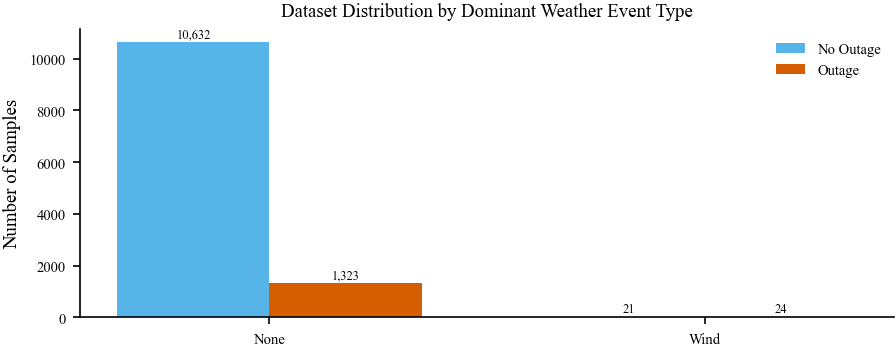

In [8]:
# Determine dominant weather event type per sample
event_types = ["drought", "fire", "flood", "heat", "ice", "wind"]
mag_cols = {et: f"cat_{et}_max_magnitude" for et in event_types}

# Build a column with the dominant event type (highest magnitude), or 'None'
mag_df = train_df[[mag_cols[et] for et in event_types]].copy()
mag_df.columns = event_types
max_mag = mag_df.max(axis=1)
dominant = mag_df.idxmax(axis=1)
dominant[max_mag == 0] = "None"

train_df_plot = train_df[["target_outage"]].copy()
train_df_plot["event_type"] = dominant.values

# Count samples per event type and outage status
order = ["None", "wind", "flood", "ice", "heat", "fire", "drought"]
ct = train_df_plot.groupby(["event_type", "target_outage"]).size().unstack(fill_value=0)
ct = ct.reindex([e for e in order if e in ct.index])

fig, ax = plt.subplots(figsize=(7.0, 2.5))
x = np.arange(len(ct))
w = 0.35

ax.bar(x - w/2, ct[0], w, color=CB_CYAN, label="No Outage")
ax.bar(x + w/2, ct[1], w, color=CB_RED, label="Outage")

ax.set_xticks(x)
ax.set_xticklabels([e.capitalize() for e in ct.index])
ax.set_ylabel("Number of Samples")
ax.set_title("Dataset Distribution by Dominant Weather Event Type")
ax.legend(frameon=False)

# Add count labels on bars
for i, (no_out, out) in enumerate(zip(ct[0], ct[1])):
    if no_out > 0:
        ax.text(i - w/2, no_out + 50, f"{no_out:,}", ha="center", va="bottom", fontsize=6)
    if out > 0:
        ax.text(i + w/2, out + 50, f"{out:,}", ha="center", va="bottom", fontsize=6)

save_fig(fig, "fig6_dataset_distribution")
plt.show()

## Summary

All six figures have been saved to `paper/figures/` in both PNG (300 DPI)
and PDF format, ready for inclusion in the IEEE-format paper.

In [9]:
import os
print("Generated figures:")
for f in sorted(FIG_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:40s}  {size_kb:6.1f} KB")

Generated figures:
  fig1_reliability_diagram.pdf                21.0 KB
  fig1_reliability_diagram.png                76.9 KB
  fig2_feature_importance.pdf                 20.9 KB
  fig2_feature_importance.png                 97.6 KB
  fig3_ablation_study.pdf                     17.6 KB
  fig3_ablation_study.png                     41.3 KB
  fig4_roc_curves.pdf                         21.8 KB
  fig4_roc_curves.png                         68.0 KB
  fig5_confusion_matrix.pdf                   24.7 KB
  fig5_confusion_matrix.png                   49.3 KB
  fig6_dataset_distribution.pdf               18.4 KB
  fig6_dataset_distribution.png               50.3 KB
